In [47]:
import time
import numpy as np
import matplotlib.pyplot as plt

from motion_planning.pdg import PDG, BiDirectionalPDG
from motion_planning.optimized_pdg_step import OptimizedPDG, BiDirectionalPDG as BiDirectionalOptimizedPDG
from motion_planning.space import PointRobot
from motion_planning.obstacle_sets import BiasedPassage
from motion_planning.database import Database, generate_database
from motion_planning.mp_sampler import MPSampler
from motion_planning.circle_approximation import ApproximationSpace

# Setup Base Robot & Environment

In [2]:
env = PointRobot()
env.set_obstacles(BiasedPassage(bias=0.5, num_walls=3))

# Setup Approximation Environment

In [3]:
env = ApproximationSpace(env, batch_size=1000, do_overapproximation=True)

/Users/pravaltelagi/motion_planning/motion_planning/circle_approximation.py:162: RuntimeWarning: invalid value encountered in divide
  gaps = (modified_segment_lengths / num_circles_per_segment)


# Generate Path Database

In [4]:
db_save_path = '../saves/optimized_pdg_example_database.pickle'
db = Database()
mp_sampler = MPSampler(env, BiasedPassage, {"num_walls": 3, "bias": 0.5})
db.populate_db(mp_sampler, num_envs=10, num_tasks_per_env=10)
db.save_to_path(db_save_path)


Connecting Edges Using knn strategy
Env 1, Task 1
Num Times Extended: 0
Env 1, Task 2
Num Times Extended: 0
Env 1, Task 3
Num Times Extended: 0
Env 1, Task 4
Num Times Extended: 0
Env 1, Task 5
Num Times Extended: 0
Env 1, Task 6
Num Times Extended: 0
Env 1, Task 7
Num Times Extended: 0
Env 1, Task 8
Num Times Extended: 0
Env 1, Task 9
Num Times Extended: 0
Env 1, Task 10
Num Times Extended: 0
DB Size: 10
Connecting Edges Using knn strategy
Env 2, Task 1
Adding Nodes, Current Size: 834
Connecting Edges Using knn strategy
Num Times Extended: 1
Env 2, Task 2
Num Times Extended: 0
Env 2, Task 3
Num Times Extended: 0
Env 2, Task 4
Num Times Extended: 0
Env 2, Task 5
Num Times Extended: 0
Env 2, Task 6
Num Times Extended: 0
Env 2, Task 7
Num Times Extended: 0
Env 2, Task 8
Num Times Extended: 0
Env 2, Task 9
Num Times Extended: 0
Env 2, Task 10
Num Times Extended: 0
DB Size: 20
Connecting Edges Using knn strategy
Env 3, Task 1
Num Times Extended: 0
Env 3, Task 2
Num Times Extended: 0
Env 3,

In [5]:
pdg = PDG(env, db_save_path)

# Create Task to Solve

In [ ]:
start, target = env.space.make_state(np.array([5.0, 5.0])), env.space.make_state(np.array([35.0, 5.0]))

# Display Task and Environment

/Users/pravaltelagi/motion_planning/motion_planning/circle_approximation.py:162: RuntimeWarning: invalid value encountered in divide
  gaps = (modified_segment_lengths / num_circles_per_segment)


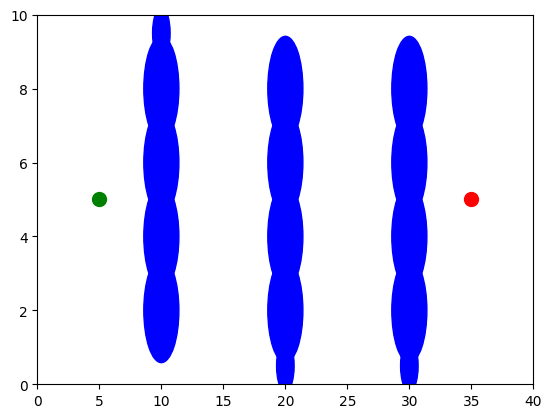

In [49]:
env.draw_environment(plt.gca())
plt.scatter(*start.value, color='green', s=100)
plt.scatter(*target.value, color='red', s=100)
plt.show()

# PDG: Compute Path for Guidance for Given Task

In [50]:
start_time = time.time()
pdg.compute_retained_paths(target)
end_time = time.time()
print(f"Time to compute paths: {end_time-start_time}")

Number of Paths to Start with: 13
Time to compute paths: 0.006711006164550781


# PDG: Search for Path

In [51]:
start_time = time.time()
path = pdg.search(start, target)
end_time = time.time()
print(f"Time to search: {end_time - start_time}", len(path))

Found Path in 0 iterations
Time to search: 0.004765987396240234 53


# PDG: Draw Search Tree

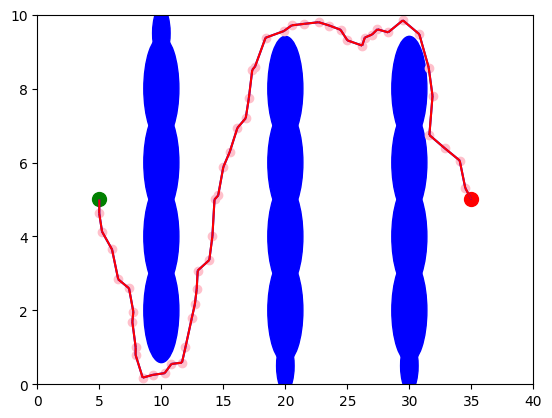

In [52]:
pdg.draw_tree(plt.gca(), path)
plt.show()

# BiDirectional PDG (BiDirPDG)

In [53]:
bidir_pdg = BiDirectionalPDG(env, db_path=db_save_path)

# BiDirPDG: Search

In [54]:
st = time.time()
path = bidir_pdg.search(start, target)
et = time.time()
print(f"Time to Search: {et - st}")

Number of Paths to Start with: 13
Number of Paths to Start with: 9
Found Path in 0 iterations
Found Path in 0 iterations
Time to search (without computing retained paths): 0.006905078887939453
Time to Search: 0.04522085189819336


/Users/pravaltelagi/motion_planning/motion_planning/utils.py:78: RuntimeWarning: invalid value encountered in divide
  gradient /= edge_length


# OptimizedPDG

In [55]:
optimized_pdg = OptimizedPDG(env, db_path=db_save_path)

# OptimizedPDG: Compute Guidance from Database Paths

In [56]:
optimized_pdg.compute_retained_paths(target)

# OptimizedPDG: Search

In [57]:
st = time.time()
path = optimized_pdg.search(start, target)
et = time.time()
print(f"Time to Search: {et - st}")

Found Path in 0 iterations
Time to Search: 0.004695892333984375


# OptimizedPDG: Draw Tree

/Users/pravaltelagi/motion_planning/motion_planning/circle_approximation.py:162: RuntimeWarning: invalid value encountered in divide
  gaps = (modified_segment_lengths / num_circles_per_segment)


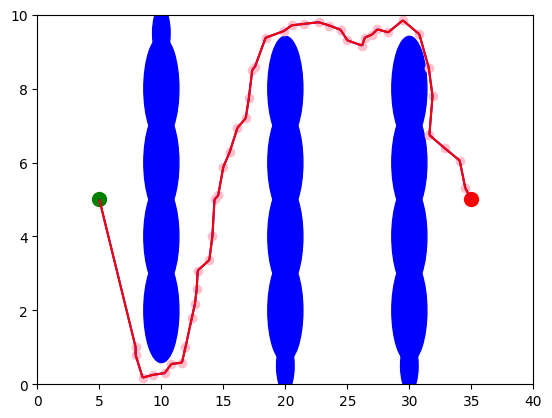

In [58]:
optimized_pdg.draw_tree(plt.gca(), path)
plt.show()

# BiDirectionalOptimizedPDG (BiDirOptimizedPDG)

In [59]:
bidirectional_optimized_pdg = BiDirectionalOptimizedPDG(env, db_save_path)

Time to Instantiate PDGs: 0.023333072662353516


# BiDirOptimizedPDG: Search

In [60]:
path = bidirectional_optimized_pdg.search(start, target)

Time to Compute Retained Paths: 0.010334968566894531
Time to Initialize Search: 0.001039743423461914
Found Path in 0 iterations
Found Path in 0 iterations
Time to search (without computing retained paths): 0.004926919937133789
Time to backtrack path: 0.002256155014038086


/Users/pravaltelagi/motion_planning/motion_planning/utils.py:78: RuntimeWarning: invalid value encountered in divide
  gradient /= edge_length


# BiDirOptimizedPDG: Draw Tree

/Users/pravaltelagi/motion_planning/motion_planning/circle_approximation.py:162: RuntimeWarning: invalid value encountered in divide
  gaps = (modified_segment_lengths / num_circles_per_segment)


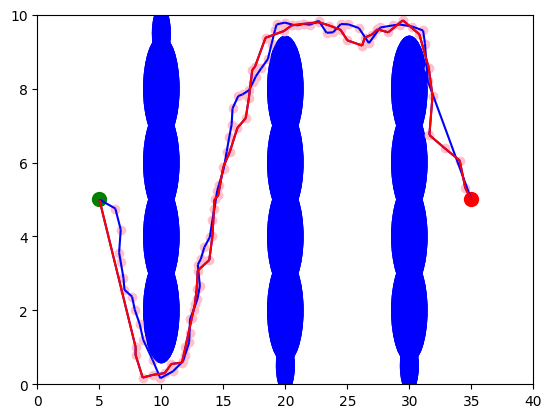

In [61]:
bidirectional_optimized_pdg.draw_tree(plt.gca(), path)
plt.show()